In [2]:
import pandas as pd

In [3]:
score_data = {
    'score': ['exceptional', 'average', 'good', 'average', 'poor'],
    'student': ['John', 'Justin', 'Bob', 'Micke', 'Jacky']
}
df6 = pd.DataFrame(score_data)
df6

,score,student
0,exceptional,John
1,average,Justin
2,good,Bob
3,average,Micke
4,poor,Jacky


In [4]:
# we generaly use numerical data instead of categorical data so replace

In [6]:
replace_map = {'exceptional': 4, 'average': 3, 'good': 2, 'poor': 1}
df6['score'] = df6['score'].replace(replace_map)
df6

,score,student
0,4,John
1,3,Justin
2,2,Bob
3,3,Micke
4,1,Jacky


In [7]:
# Pandas Pivot and Pivot Table

In [8]:
#Create the DataFrame
data = {
    'date': ['5/1/2017', '5/1/2017', '5/1/2017',
             '5/2/2017', '5/2/2017', '5/2/2017',
             '5/3/2017', '5/3/2017', '5/3/2017'],

    'city': ['new york', 'mumbai', 'beijing',
             'new york', 'mumbai', 'beijing',
             'new york', 'mumbai', 'beijing'],

    'temperature': [65,75,80,
                    66,78,77,
                    68,82,79],

    'humidity': [56,80,26,
                 58,83,30,
                 60,85,35]}
df = pd.DataFrame(data)
print(df)

       date      city  temperature  humidity
0  5/1/2017  new york           65        56
1  5/1/2017    mumbai           75        80
2  5/1/2017   beijing           80        26
3  5/2/2017  new york           66        58
4  5/2/2017    mumbai           78        83
5  5/2/2017   beijing           77        30
6  5/3/2017  new york           68        60
7  5/3/2017    mumbai           82        85
8  5/3/2017   beijing           79        35


In [9]:
#Basic Pivot
pivoted_df = df.pivot(
    index='date',
    columns='city'
)
pivoted_df

temperature                 humidity                
city         beijing mumbai new york  beijing mumbai new york
date                                                         
5/1/2017          80     75       65       26     80       56
5/2/2017          77     78       66       30     83       58
5/3/2017          79     82       68       35     85       60

In [10]:
# Explanation

# The pivot() function reshapes the DataFrame.

# Here,

# index='date' Date becomes the row index. columns='city' Every unique city becomes a separate column. Since values is not specified, Pandas displays all remaining columns (temperature and humidity).

# # The output becomes easier to compare weather data across cities.

In [11]:
#Pivot with Specific Values
temp_pivot = df.pivot(
    index='date',
    columns='city',
    values='temperature'
)

print(temp_pivot)

city      beijing  mumbai  new york
date                               
5/1/2017       80      75        65
5/2/2017       77      78        66
5/3/2017       79      82        68


In [12]:
# Pivot Table
pivot_table = df.pivot_table(
    index='city',
    columns='date',
    aggfunc='sum'
)

print(pivot_table)
# with pivot table, we can use aggregate for further analysis

         humidity                   temperature                  
date     5/1/2017 5/2/2017 5/3/2017    5/1/2017 5/2/2017 5/3/2017
city                                                             
beijing        26       30       35          80       77       79
mumbai         80       83       85          75       78       82
new york       56       58       60          65       66       68


In [13]:
# Explanation

# pivot_table() is similar to pivot(), but it can also perform aggregation.

# Here,

# Rows → City Columns → Date Aggregation Function → Sum

# Since there are no duplicate records in this dataset, the output is almost the same as Pivot.

# The real advantage of pivot_table() appears when duplicate records exist.



In [14]:
#Create Dataset with Duplicate Records
data2 = {
    'date': ['5/1/2017','5/1/2017','5/1/2017','5/1/2017',
             '5/2/2017','5/2/2017','5/2/2017','5/2/2017'],

    'city': ['new york','new york','mumbai','mumbai',
             'new york','new york','mumbai','mumbai'],

    'temperature': [65,61,75,78,
                    70,72,82,80],

    'humidity': [56,54,80,83,
                 60,62,85,26]
}
df2 = pd.DataFrame(data2)
print(df2)

       date      city  temperature  humidity
0  5/1/2017  new york           65        56
1  5/1/2017  new york           61        54
2  5/1/2017    mumbai           75        80
3  5/1/2017    mumbai           78        83
4  5/2/2017  new york           70        60
5  5/2/2017  new york           72        62
6  5/2/2017    mumbai           82        85
7  5/2/2017    mumbai           80        26


In [15]:
#Pivot Table with Duplicate Records
pivot_table2 = df2.pivot_table(
    index='city',
    columns='date',
    aggfunc='sum'
)

print(pivot_table2)

         humidity          temperature         
date     5/1/2017 5/2/2017    5/1/2017 5/2/2017
city                                           
mumbai        163      111         153      162
new york      110      122         126      142


In [16]:
# pivot_table() successfully handles duplicate records.

# Instead of showing an error, it combines duplicate values using the specified aggregation function.

# Since

# aggfunc='sum'

# is used,

# duplicate values are added together.

# Example:

# For New York on 5/1/2017,

# 65 + 61 = 126

# Similarly,

# For Mumbai on 5/2/2017,

# 82 + 80 = 162

# This is why pivot_table() is preferred when duplicate records are present.

In [18]:
temp_analysis = df.pivot_table( index='city', columns='date', values='temperature', aggfunc='mean' )
print(temp_analysis)
#use of mean for replacing duplicate value

date      5/1/2017  5/2/2017  5/3/2017
city                                  
beijing       80.0      77.0      79.0
mumbai        75.0      78.0      82.0
new york      65.0      66.0      68.0


In [19]:
df= pd.read_csv('/Superstore.csv')

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,08-11-2018,11-11-2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,08-11-2018,11-11-2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,12-06-2018,16-06-2018,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,11-10-2017,18-10-2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,11-10-2017,18-10-2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
pv1= df.pivot_table(index='Region',
                    columns='Category',
                    values='Sales',
                    aggfunc='sum')
pv1.head()

Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


In [28]:
pv2= df.pivot_table(index='Region',columns='Sub-Category',values='Profit',aggfunc='mean')
pv2.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Region,,,,,,,,,,,,,,,,,
Central,39.626397,-21.452175,6.790677,-2.851467,-39.958086,42.809884,975.552581,30.127598,4.302156,-19.054716,14.119466,-70.765076,21.719316,61.615133,9.380174,-18.385781,-49.439589
East,54.348856,66.598519,8.333089,25.608942,-16.680454,55.701015,851.142090,24.492014,4.327718,20.782357,10.554019,187.260619,23.850188,45.274581,34.666823,-20.627414,-137.817251
South,54.722988,50.912835,7.454835,15.856358,47.838993,75.137378,522.700957,27.138463,5.990279,20.864745,16.011882,-79.938500,26.909780,76.909109,17.767941,0.064734,-90.648194
West,63.893792,60.744632,9.496388,34.175800,-20.581396,19.456929,773.089404,28.488991,3.822093,25.135758,19.854503,-15.869908,26.931636,32.890768,32.501211,9.073138,12.781097


In [29]:
# Matplot and seaborn library

In [30]:
#visualization
#client visualization-- excel,powerbi,tableau
#self visualization-- matplotlib,seaborn

In [31]:
!pip install pandas
import pandas as pd

In [32]:
df=pd.read_csv(r"/Superstore.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,08-11-2018,11-11-2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,08-11-2018,11-11-2018,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,12-06-2018,16-06-2018,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,11-10-2017,18-10-2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,11-10-2017,18-10-2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2016-110422,21-01-2016,23-01-2016,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2019-121258,26-02-2019,03-03-2019,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2019-121258,26-02-2019,03-03-2019,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2019-121258,26-02-2019,03-03-2019,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [35]:
!pip install matplotlib
import matplotlib.pyplot as plt

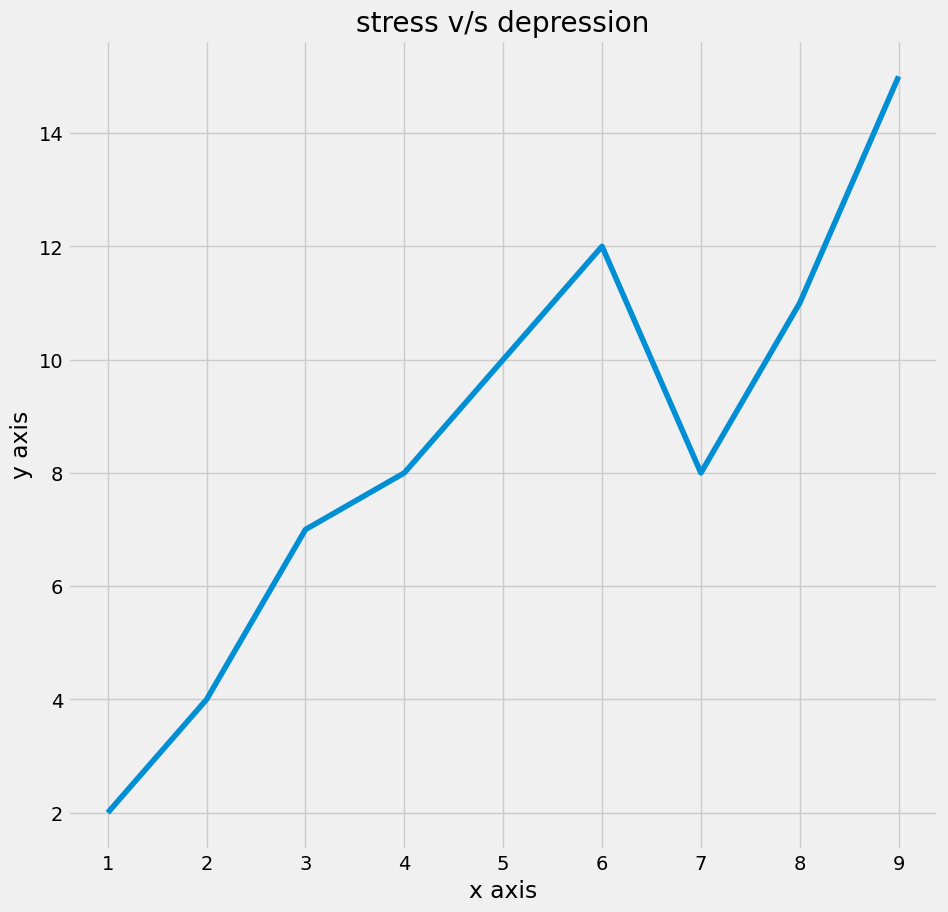

In [39]:
plt.figure(figsize=(10,10))
x=[1,2,3,4,5,6,7,8,9]
y=[2,4,7,8,10,12,8,11,15]
plt.plot(x,y)
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('stress v/s depression')
plt.grid(plt.style)
plt.savefig('line chart')
plt.show()

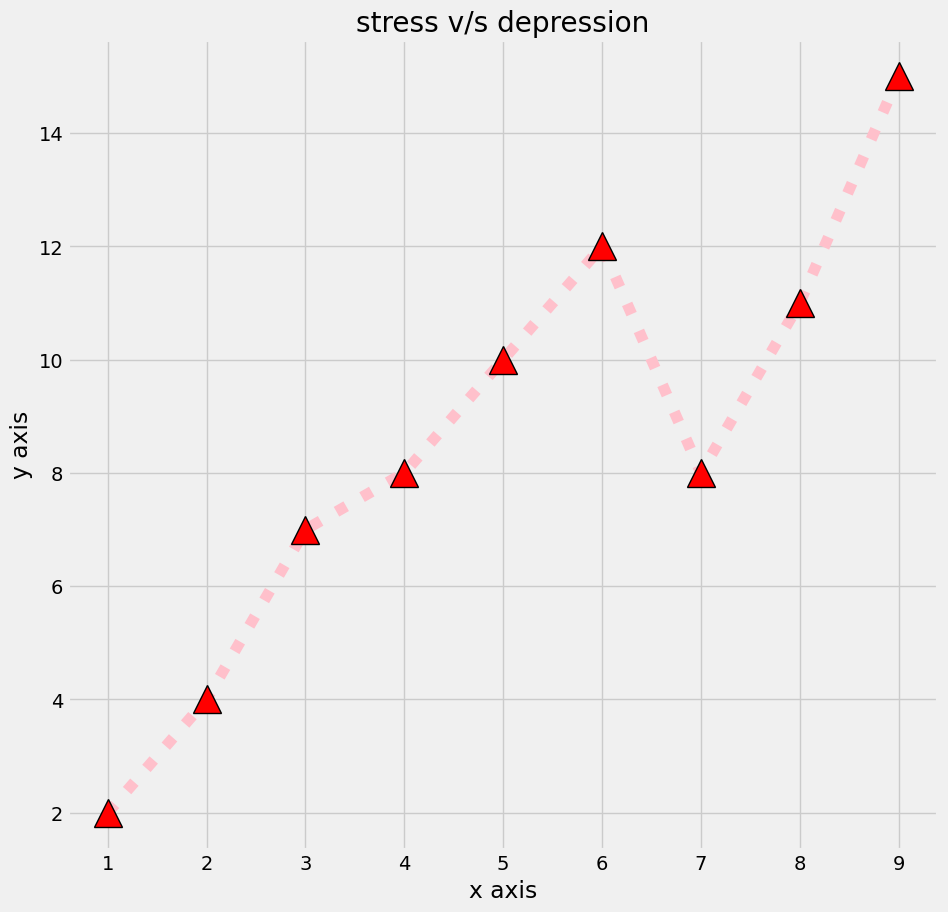

In [50]:
# trying out diff styles
from matplotlib.typing import LineStyleType
plt.figure(figsize=(10,10))
x=[1,2,3,4,5,6,7,8,9]
y=[2,4,7,8,10,12,8,11,15]
plt.plot(x,y,color='pink',linewidth=8, linestyle=':', marker='^', markersize=20,markerfacecolor='red',
    markeredgecolor='black')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('stress v/s depression')
plt.grid(plt.style)
plt.savefig('line chart')
plt.show()

In [40]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [51]:
df['Order Date'].head(5)
#for checking first 5 dates

,Order Date
0,08-11-2018
1,08-11-2018
2,12-06-2018
3,11-10-2017
4,11-10-2017


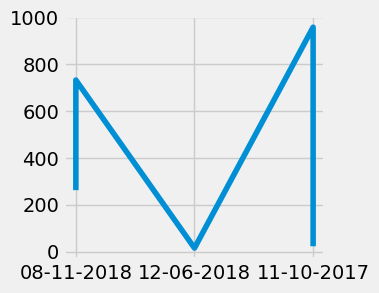

In [52]:
#creating plot line chart for our data set
plt.figure(figsize=(3,3))

plt.plot(df['Order Date'].head(5),df['Sales'].head(5))

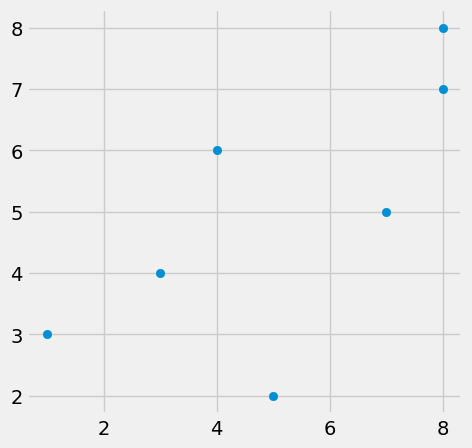

In [53]:
x=[1,4,8,3,5,7,8]
y=[3,6,8,4,2,5,7]
plt.figure(figsize=(5,5))
plt.scatter(x,y)

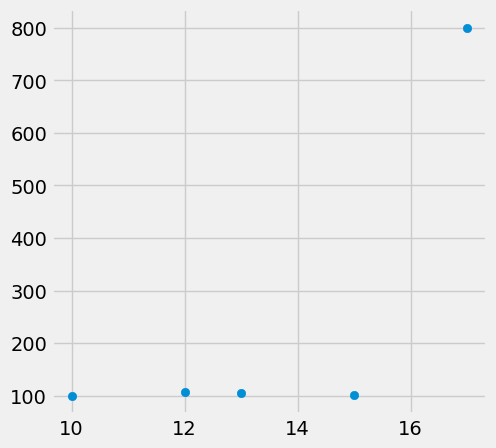

In [55]:
x=[10,12,13,15,17]
y=[100,108,105,101,800]
plt.figure(figsize=(5,5))
plt.scatter(x,y)
#here 800 is way bigger than other values and can be seen in the scatter plot
# hence scatter plot is used for outlier detection

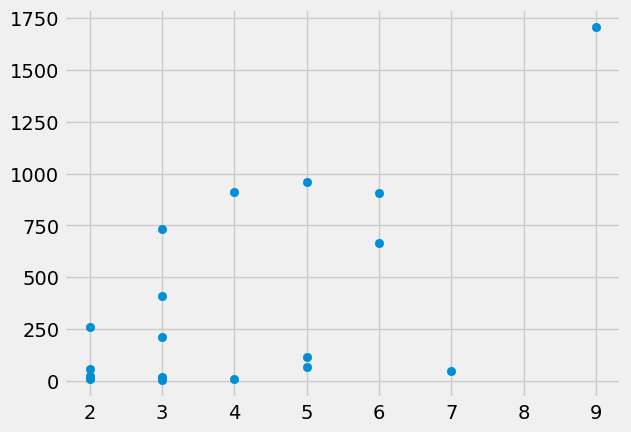

In [57]:
# scatter plot for qty vs sales for our dataset first 20
plt.scatter(df['Quantity'].head(20),df['Sales'].head(20))

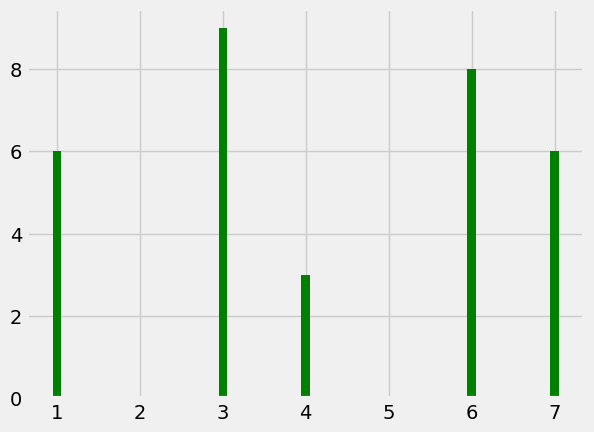

In [62]:
# bar plot / bar graph
plt.bar([1,3,6,7,4],[6,9,8,6,3],color='green', width=0.1)
plt.show()

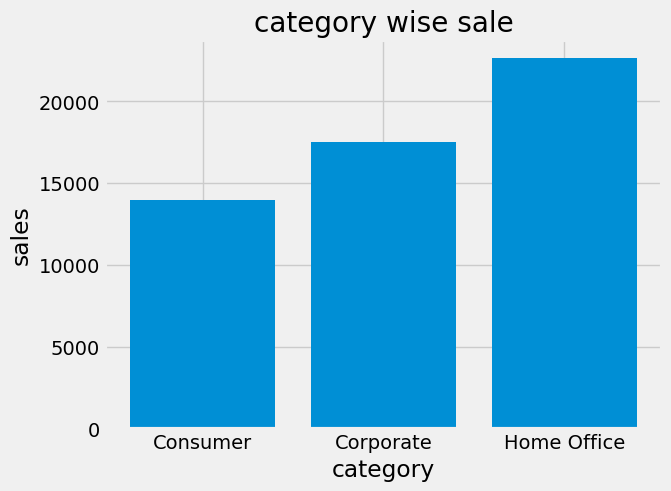

In [63]:
# to implement bar graph on our dataset to show segment wise sales
plt.bar(df['Segment'],df['Sales'])
plt.title("category wise sale")
plt.xlabel("category")
plt.ylabel("sales")
plt.show()

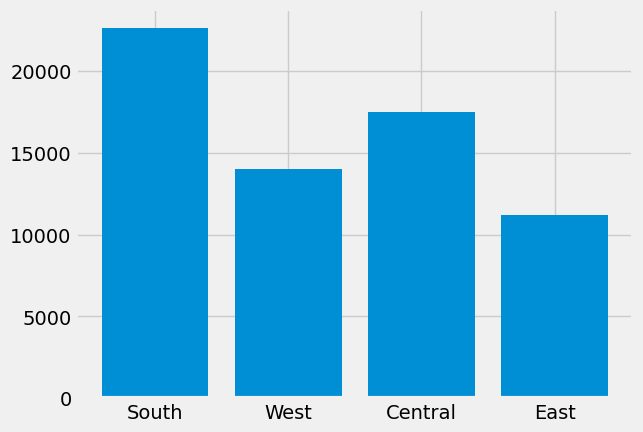

In [64]:
plt.bar(df['Region'],df['Sales'])
plt.show()

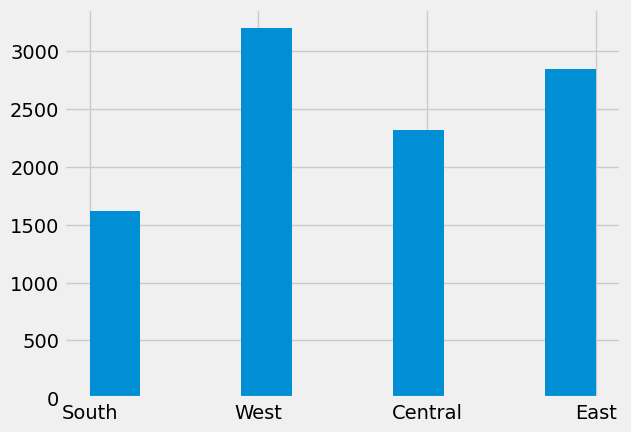

In [67]:
# shows how many records region wise, we use histogram
plt.hist(df["Region"])
plt.savefig('histplot.jpg')

(array([5386., 1462.,  856.,  472.,  559.,  407.,  242.,  279.,  193.,
         138.]),
 array([  0.,  53., 106., 159., 212., 265., 318., 371., 424., 477., 530.]),
 <BarContainer object of 10 artists>)

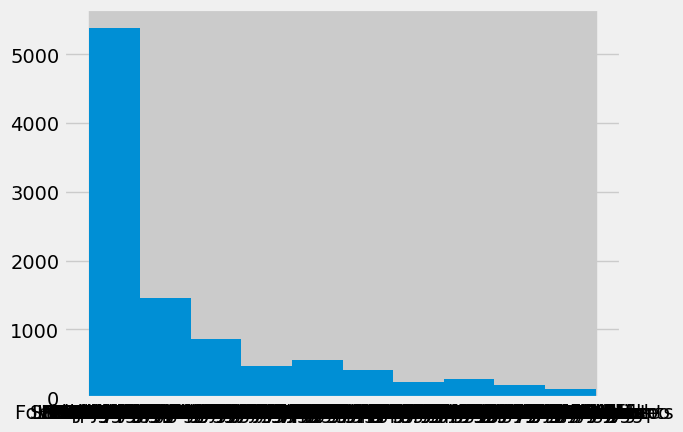

In [70]:
# to see city wise records
plt.hist(df["City"])

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


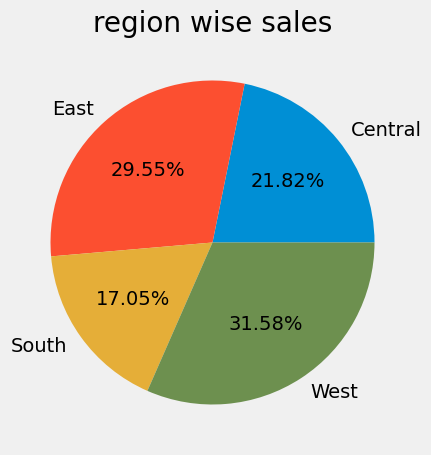

In [72]:
obj= df.groupby('Region')['Sales'].sum()
print(obj)

plt.figure(figsize=(5,5))
plt.pie(obj, labels= obj.index, autopct='%1.2f%%')
plt.title('region wise sales')
plt.savefig('piechart.jpg')
plt.show()


In [73]:
!pip install seaborn

In [74]:
import seaborn as sns

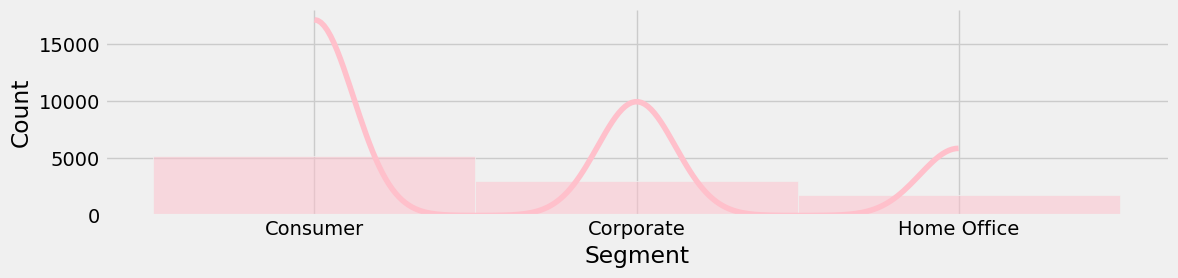

In [78]:
# distribution plot to show distrubutin
sns.displot(df['Segment'], kde=True, height=3, aspect=4, color='pink') #kde - kernel density estimate

In [81]:
sns.displot #get help docs for this module

<function seaborn.distributions.displot(data=None, *, x=None, y=None, hue=None, row=None, col=None, weights=None, kind='hist', rug=False, rug_kws=None, log_scale=None, legend=True, palette=None, hue_order=None, hue_norm=None, color=None, col_wrap=None, row_order=None, col_order=None, height=5, aspect=1, facet_kws=None, **kwargs)>

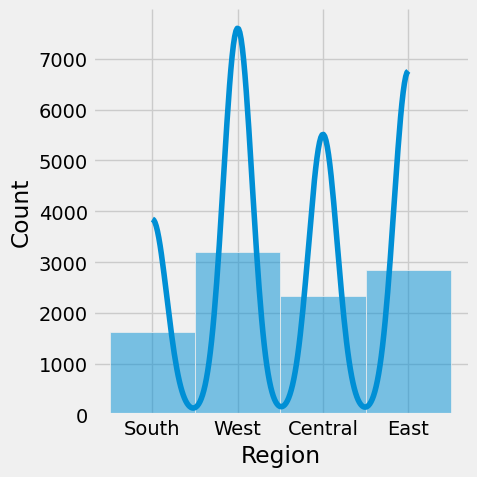

In [82]:
sns.displot(df['Region'],kde=True)

In [83]:
# loading the seaborn inbuilt data set
df1=sns.load_dataset('mpg')
df1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


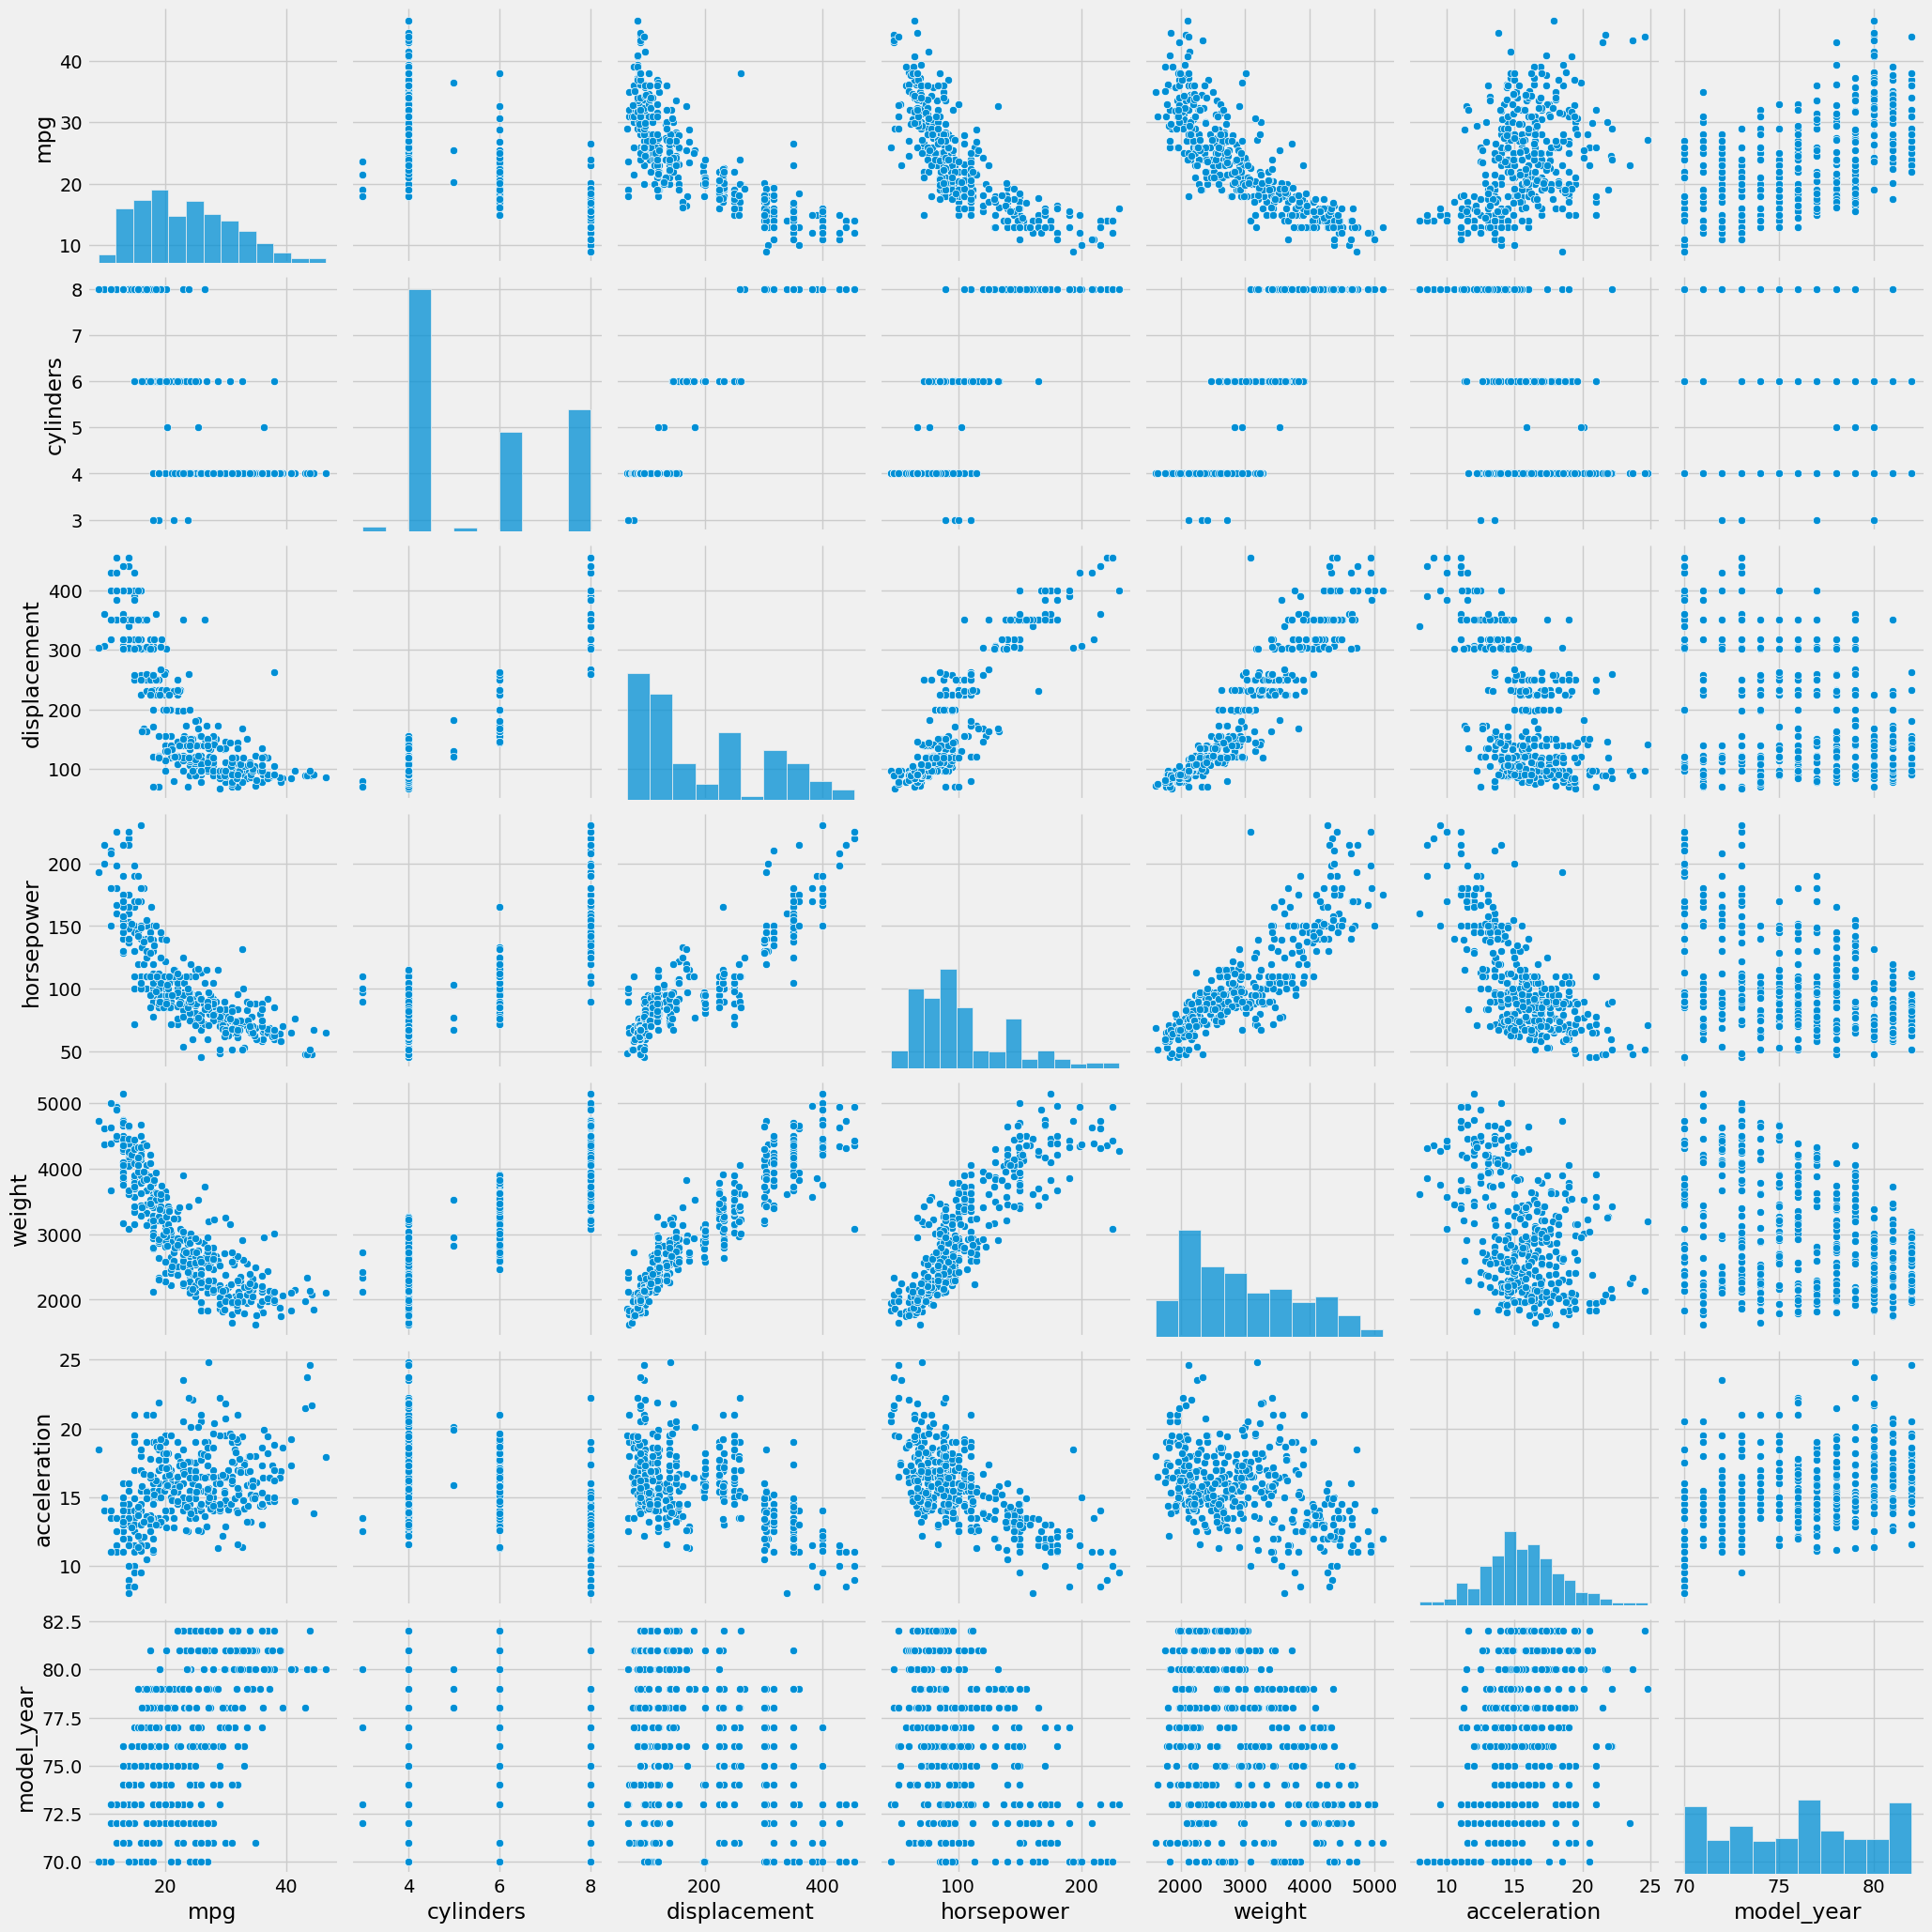

In [85]:
# sns pairplot plots each feature with other to show us relations
sns.pairplot(df1,aspect=1,height=3)